In [1]:
import numpy as np

#-------------------------#
import ipympl

%matplotlib ipympl
# %matplotlib widget
#-------------------------#
import matplotlib.pyplot as plt
import mpl_interactions.ipyplot as iplt
#-------------------------#

from matplotlib.patches import Rectangle


In [2]:
def show_cube(cube,**kwargs):
    return Rectangle(
        (cube.center[0]-cube.distance,cube.center[1]-cube.distance),   # lower-left corner
        cube.distance*2, #height
        cube.distance*2, #width
        **kwargs)

In [3]:
class Cube:
    def __init__(self,center,distance):
        self.center=center
        self.distance=distance
        self.dim=len(center)

        self.vertex_points()
        
    def sign(self,i,j):
        r'''
            This generates an alternating pattern of signs that enumerates all 2^d
            possible sign vectors of a d-dimensional cube.
            
            Each sign vector tells us how to move from the center of the cube to one
            vertex:
            
                vertex = center + sign_vector * distance
            
            The same sign vectors can also be used to locate the centers of the
            subcubes after subdivision:
            
                child_center = center + sign_vector * (distance / 2)
            

            My way of thinking:
            If you imagine a circle divided into j equal picies with \delta\theta=\pi/(2^(j-1)), 
            then the sign can be defined as + if \theta = i*\delta\theta <= \pi and - if \theta = i*\delta\theta > \pi.
            
            Alternative way of thinking:
            For each coordinate j, the sign is a 'square wave' as a function of the
            vertex (or child) index i. The last coordinate flips every step, the previous
            one flips every two steps, the previous one every four steps, and so on.
            Equivalently, coordinate j flips every 2^(d-j-1) steps.

            This is the idea this fucntion follows.
        '''
        #shift to call i,j as a list that start from 0 at 0
        i=i+1
        j=j+1
        
        dt=1/2**(j-1)#the step in units of \pi
        t=(i-1)#the steps you take, i=\theta/\delta\theta

        semicircle=np.floor((t*dt)%2)#this checks whether you are in the upper or lower half of the circle
        return int((-1)**semicircle)#this gives you the sign
    
    def vertex_points(self):
        '''generate all vertex points of the cube'''
        
        self.vertices=[]
        for bound in range(2**self.dim):
            self.vertices.append([self.center[d]+self.distance*self.sign(bound,d) for d in range(self.dim)])


    def volume(self):
        '''Return the volume of this cube.'''
        return (2 * self.distance) ** self.dim

    
    def check_point(self,point):
        '''check whether point is inside this cube'''
        for i in range(self.dim):
            if point[i]>self.center[i]+self.distance or point[i]<self.center[i]-self.distance:
                return False
        return True

    def random_point(self):
        '''generate a random point in this cube'''
        
        point=[]
        for d in range(self.dim):
            _M=self.center[d]+self.distance
            _m=self.center[d]-self.distance
            point.append(np.random.rand()*(_M-_m)+_m)
            
        return point
    
    
def overlap_check(cube_1,cube_2):
    '''Check if cube_1 overlaps with cube_2. This means that they share a volume.'''
    for vertex in cube_1.vertices:
        if cube_2.check_point(vertex):
            return True
    for vertex in cube_2.vertices:
        if cube_1.check_point(vertex):
            return True
    return False

In [56]:
class DTree:
    '''
    The DTree class recursively subdivides the space.
    '''
    def __init__(self,boundary,max_depth=np.inf,score=0,depth=0,parent=None):
        '''
        boundary: an instance of Cube. It is the cube that defines this "node" of the tree.
        
        max_depth: number of allowed subdivisions
        
        score: This is a number. I will use this to assign values to each cube and later decide to subdivide it or not. 
        
        depth: depth of current node

        parent: the parent node
        '''
        
        #We deal with cubes, but use the dim when you can. It will be easier to generalize later.
        self.dim=boundary.dim
            
        self.boundary=boundary
        self.score=score
        self.max_depth=max_depth
        self.depth=depth
        
        #List of intances of DTree. This will hold the potential cubes.
        #Each instance of DTree has either 0 or dim**2 children.
        self.children=[0 for i in range(2**self.dim)]  
        self.has_children=False
        
        self.max_reached = self.depth >= self.max_depth
        self.parent=parent
        
    def subdivide(self):
        '''Subdivide the current cube'''
        if self.depth>=self.max_depth:
            return
            
        self.has_children=True
        new_distance = self.boundary.distance/2. #the distance of all new cubes
        for i in range(2**self.dim):
            new_center = [ self.boundary.sign(i,d)*new_distance + self.boundary.center[d] for d in range(self.dim)]
            child = Cube( new_center , new_distance )
            self.children[i]=DTree( boundary=child, max_depth=self.max_depth, score=0, depth=self.depth+1,parent = self)
        if self.children[0].max_reached:
            self.assign_max_reached()
        
    def assign_score(self, score_function):
        '''
        Run score_function in each cube to assign the scores. Note that I want to 
        assign a value at the last notes because these are the ones that can be
        subdivided.
        
        score_function: a function that takes a node (not just a cube) and returns a number.
        '''
        if self.max_reached:
            return
        if self.has_children:
            for node in self.children:
                node.assign_score(score_function)
        else:
            self.score=score_function(self)


    def conditional_subdivision(self, condition):
        '''
        check the score and subdivid if condition returns True.
        
        condition: a function that takes a value and returns True or False.
        '''
        if self.max_reached:
            return

        if self.has_children:
            for node in self.children:
                node.conditional_subdivision(condition)
        else:
            if condition(self.score):
                self.subdivide()

    def assign_max_reached(self):
        '''
        An end node has max_reached=True if its depth is >= max_depth.
    
        An internal node has max_reached=True if **all of its children** have
        max_reached=True. The reason is that I don't want to stop subdivision
        of a node if another node has already reached its maximum depth. 
    
        After updating this node, propagate the update to the parent.
        '''
        if self.has_children:
            self.max_reached = True
            for node in self.children:
                if not node.max_reached:
                    self.max_reached = False
        else:
            self.max_reached = self.depth >= self.max_depth
    
        if self.parent is not None:
            self.parent.assign_max_reached()        
 
    
    def get_all_cubes(self):
        '''Get all the cubes of the tree and its children recursively'''
        cubes = [(self.depth,self.boundary)]
    
        if self.has_children:
            for i in self.children:
                for c in i.get_all_cubes():
                    cubes.append(c)
        return cubes


    def get_cubes(self,cubes = None):
        '''Get the end cubes of the tree'''
        if cubes is None:
            cubes=[]
    
        if self.has_children:
            for node in self.children:
                node.get_cubes(cubes)
        else:
            cubes.append((self.depth,self.boundary))
        return cubes                

    
    def get_end_nodes(self, nodes=None):
        '''
        Return the end nodes of the tree.
        '''
        if nodes is None:
            nodes = []
    
        if self.has_children:
            for node in self.children:
                node.get_end_nodes(nodes)
        else:
            nodes.append(self)
    
        return nodes
    
    def get_scores(self,scores = None):
        '''
        return a list of scores of the end node
        '''
        if scores is None:
            scores=[]
        
        if self.has_children:
            for node in self.children:
                node.get_scores(scores)
        else:
            scores.append(self.score)
        return scores


    def random_points(self,number_of_points):
        '''
        Generate random points inside the cubes. 
        I want to choose a random cube according to
        the distribution  p_i ~ 1/node[i].boundary.volume().   
        
        To do this, I choose a random node, and sample inside it.
        '''
        nodes=self.get_end_nodes()
        points=[]
        while len(points)<number_of_points:
            
            i=np.random.choice( len(nodes) )
            
            points.append(nodes[i].boundary.random_point())
        return points




In [77]:
#generate a number of points from a gaussian
points = np.random.normal(0,0.3,(5000,2))

In [78]:
#at a node, check the number of points
def number_of_points(node):
    score=0
    for point in points:
        #avoid branches by adding 1 or 0 depending on true or false
        score+=float(node.boundary.check_point(point))        
    return score

In [79]:
tree=DTree(Cube([0,0],1),15)
for _ in range(15):
    
    tree.assign_score( score_function = number_of_points )
    
    tree.conditional_subdivision(lambda score: score>10)

In [80]:
cubes=tree.get_cubes()

cube_points=np.array(tree.random_points(10000))

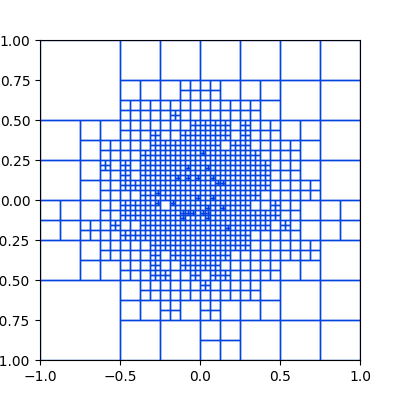

In [85]:
fig=plt.figure(figsize=(4,4))
fig.subplots_adjust(bottom=0.1, left=0.1, top = 0.9, right=0.9,wspace=0.0,hspace=0.5)

sub = fig.add_subplot(111)


for depth,c in cubes:
    sub.add_patch(show_cube(c,fill=False,color='xkcd:blue'))

# sub.scatter(points[:,0],points[:,1],s=1,color='xkcd:red')
# sub.scatter(cube_points[:,0],cube_points[:,1],s=1,edgecolor='xkcd:black',facecolors="none")

sub.set_xlim(-1,1)
sub.set_ylim(-1,1)
plt.show()